In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
BASE_DIR = Path("..")

EDA_DATA_PATH = BASE_DIR / "data" / "processed" / "creepypastas_eda_ready.csv"
FRACTURE_DATA_PATH = BASE_DIR / "data" / "processed" / "creepypastas_fracture_index.csv"

df = pd.read_csv(EDA_DATA_PATH)

df.head()

,title,story_text,text_lower,rating,rating_numeric,story_length_chars,word_count,tags,categories,estimated_reading_time,publish_date,primary_category
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu...",9.25,9.25,19493,3560,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",12 minutes,2020-02-20,Drugs and Addictions
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a be...","i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a be...",9.13,9.13,20837,3919,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",14 minutes,2020-07-22,Madness
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...","i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ...",9.12,9.12,10859,2135,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes",8 minutes,2019-12-10,Abductions and Kidnappings
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...","when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ...",9.12,9.12,4150,768,Ashley Rose Wellman,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho...",3 minutes,2019-07-13,Beings and Entities
4,He Who Wanders,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...","i missed the scorching wind of andalusia. how it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. i missed the smell of the valley ...",9.12,9.12,32767,6021,Simon Simonian,Beings and Entities,22 minutes,2017-01-24,Beings and Entities


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 3478
Columns: 12
<class 'pandas.DataFrame'>
RangeIndex: 3478 entries, 0 to 3477
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   3478 non-null   str    
 1   story_text              3478 non-null   str    
 2   text_lower              3478 non-null   str    
 3   rating                  3478 non-null   float64
 4   rating_numeric          3478 non-null   float64
 5   story_length_chars      3478 non-null   int64  
 6   word_count              3478 non-null   int64  
 7   tags                    3478 non-null   str    
 8   categories              3478 non-null   str    
 9   estimated_reading_time  3478 non-null   str    
 10  publish_date            3478 non-null   str    
 11  primary_category        3478 non-null   str    
dtypes: float64(2), int64(2), str(8)
memory usage: 326.2 KB


In [4]:
required_columns = [
    "title",
    "story_text",
    "text_lower",
    "rating_numeric",
    "word_count"
]

df[required_columns].head()

,title,story_text,text_lower,rating_numeric,word_count
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu...",9.25,3560
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a be...","i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a be...",9.13,3919
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...","i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ...",9.12,2135
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...","when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ...",9.12,768
4,He Who Wanders,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...","i missed the scorching wind of andalusia. how it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. i missed the smell of the valley ...",9.12,6021


In [5]:
fracture_keywords = {
    "reality_fracture": [
        "dream", "hallucination", "impossible", "real", "unreal",
        "dimension", "world", "mirror", "distorted", "vision",
        "reality", "strange", "wrong", "changed", "loop",
        "time", "space", "universe", "alternate", "parallel"
    ],
    
    "control_loss": [
        "trapped", "escape", "helpless", "followed", "watched",
        "locked", "panic", "unable", "forced", "chased",
        "couldn't", "couldn", "afraid", "fear", "screamed",
        "ran", "running", "hide", "hiding", "stuck"
    ],
    
    "body_boundary": [
        "blood", "flesh", "skin", "bones", "teeth",
        "infection", "wound", "body", "eyes", "mouth",
        "face", "hands", "head", "pain", "scar",
        "cut", "bleeding", "rot", "limbs", "stomach"
    ],
    
    "nonhuman_presence": [
        "creature", "entity", "demon", "shadow", "thing",
        "monster", "presence", "voice", "figure", "whisper",
        "ghost", "spirit", "alien", "beast", "something",
        "watching", "eyes", "dark", "unknown", "inhuman"
    ],
    
    "liminal_space": [
        "hallway", "basement", "attic", "woods", "room",
        "door", "stairs", "corridor", "house", "road",
        "forest", "tunnel", "school", "hospital", "apartment",
        "window", "street", "place", "building", "corner"
    ],
    
    "ritual_logic": [
        "rule", "ritual", "curse", "summon", "symbol",
        "circle", "prayer", "sacrifice", "offering", "deal",
        "spell", "magic", "witch", "demon", "altar",
        "blood", "chant", "forbidden", "promise", "warning"
    ],
    
    "domestic_corruption": [
        "home", "mother", "father", "child", "family",
        "bedroom", "kitchen", "neighbor", "school", "friend",
        "house", "parents", "sister", "brother", "wife",
        "husband", "children", "baby", "door", "room"
    ],
    
    "residual_impact": [
        "haunted", "nightmare", "remember", "sleep", "disturbed",
        "scarred", "unforgettable", "thinking", "afraid", "after",
        "dreams", "memory", "memories", "still", "never",
        "again", "wake", "woke", "fear", "mind"
    ]
}

In [6]:
def count_keywords(text, keywords):
    """
    Count how many times a group of keywords appears in a text.
    
    Parameters:
    text: story text in lowercase
    keywords: list of words associated with one fracture dimension
    
    Returns:
    total number of keyword matches
    """
    
    if pd.isna(text):
        return 0
    
    text = str(text).lower()
    
    total_count = 0
    
    for keyword in keywords:
        pattern = r"\b" + re.escape(keyword.lower()) + r"\b"
        matches = re.findall(pattern, text)
        total_count += len(matches)
        
    return total_count

In [7]:
for fracture_name, keywords in fracture_keywords.items():
    score_column = fracture_name + "_score"
    df[score_column] = df["text_lower"].apply(lambda text: count_keywords(text, keywords))

df.head()

,title,story_text,text_lower,rating,rating_numeric,story_length_chars,word_count,tags,categories,estimated_reading_time,publish_date,primary_category,reality_fracture_score,control_loss_score,body_boundary_score,nonhuman_presence_score,liminal_space_score,ritual_logic_score,domestic_corruption_score,residual_impact_score
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu...",9.25,9.25,19493,3560,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",12 minutes,2020-02-20,Drugs and Addictions,34,15,39,10,23,1,16,37
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a be...","i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a be...",9.13,9.13,20837,3919,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",14 minutes,2020-07-22,Madness,30,11,27,31,31,0,26,50
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...","i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ...",9.12,9.12,10859,2135,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes",8 minutes,2019-12-10,Abductions and Kidnappings,10,11,21,15,19,1,37,23
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...","when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ...",9.12,9.12,4150,768,Ashley Rose Wellman,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho...",3 minutes,2019-07-13,Beings and Entities,3,4,2,15,2,1,4,13
4,He Who Wanders,"I missed the scorching wind of Andalusia. How it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. I missed the smell of the valley ...","i missed the scorching wind of andalusia. how it pours sunlight onto your face, toying with eyelashes, flattening dry sand against cheeks and milling around hair. i missed the smell of the valley ...",9.12,9.12,32767,6021,Simon Simonian,Beings and Entities,22 minutes,2017-01-24,Beings and Entities,25,25,40,47,47,6,24,63


In [8]:
fracture_score_columns = [
    "reality_fracture_score",
    "control_loss_score",
    "body_boundary_score",
    "nonhuman_presence_score",
    "liminal_space_score",
    "ritual_logic_score",
    "domestic_corruption_score",
    "residual_impact_score"
]

df[["title"] + fracture_score_columns].head()

,title,reality_fracture_score,control_loss_score,body_boundary_score,nonhuman_presence_score,liminal_space_score,ritual_logic_score,domestic_corruption_score,residual_impact_score
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",34,15,39,10,23,1,16,37
1,A Shattered Life,30,11,27,31,31,0,26,50
2,My Father Punished Me When I Talked to Ghosts,10,11,21,15,19,1,37,23
3,Distorted Warning Signals,3,4,2,15,2,1,4,13
4,He Who Wanders,25,25,40,47,47,6,24,63


In [9]:
for column in fracture_score_columns:
    normalized_column = column.replace("_score", "_normalized")
    df[normalized_column] = df[column] / df["word_count"]

normalized_fracture_columns = [
    column.replace("_score", "_normalized")
    for column in fracture_score_columns
]

df[["title", "word_count"] + normalized_fracture_columns].head()

,title,word_count,reality_fracture_normalized,control_loss_normalized,body_boundary_normalized,nonhuman_presence_normalized,liminal_space_normalized,ritual_logic_normalized,domestic_corruption_normalized,residual_impact_normalized
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",3560,0.009551,0.004213,0.010955,0.002809,0.006461,0.000281,0.004494,0.010393
1,A Shattered Life,3919,0.007655,0.002807,0.006890,0.007910,0.007910,0.000000,0.006634,0.012758
2,My Father Punished Me When I Talked to Ghosts,2135,0.004684,0.005152,0.009836,0.007026,0.008899,0.000468,0.017330,0.010773
3,Distorted Warning Signals,768,0.003906,0.005208,0.002604,0.019531,0.002604,0.001302,0.005208,0.016927
4,He Who Wanders,6021,0.004152,0.004152,0.006643,0.007806,0.007806,0.000997,0.003986,0.010463


In [10]:
df["horror_fracture_index"] = df[normalized_fracture_columns].mean(axis=1)

df[["title", "rating_numeric", "word_count", "horror_fracture_index"]].head()

,title,rating_numeric,word_count,horror_fracture_index
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,3560,0.006145
1,A Shattered Life,9.13,3919,0.006571
2,My Father Punished Me When I Talked to Ghosts,9.12,2135,0.008021
3,Distorted Warning Signals,9.12,768,0.007161
4,He Who Wanders,9.12,6021,0.005751


In [11]:
df["horror_fracture_index"].describe()

count    3478.000000
mean        0.007197
std         0.002433
min         0.000000
25%         0.005535
50%         0.006937
75%         0.008635
max         0.023923
Name: horror_fracture_index, dtype: float64

In [12]:
top_fracture_stories = df.sort_values("horror_fracture_index", ascending=False).head(20)

top_fracture_stories[
    [
        "title",
        "rating_numeric",
        "word_count",
        "horror_fracture_index"
    ] + normalized_fracture_columns
]

,title,rating_numeric,word_count,horror_fracture_index,reality_fracture_normalized,control_loss_normalized,body_boundary_normalized,nonhuman_presence_normalized,liminal_space_normalized,ritual_logic_normalized,domestic_corruption_normalized,residual_impact_normalized
2086,Upstairs,7.50,209,0.023923,0.004785,0.004785,0.004785,0.028708,0.052632,0.000000,0.081340,0.014354
284,In the Kitchen,8.87,68,0.022059,0.000000,0.014706,0.000000,0.000000,0.044118,0.000000,0.117647,0.000000
3335,The Doorway,5.12,76,0.019737,0.026316,0.000000,0.000000,0.000000,0.052632,0.000000,0.052632,0.026316
1529,Déjà Vu,7.95,69,0.018116,0.043478,0.000000,0.000000,0.028986,0.000000,0.000000,0.028986,0.043478
2880,The Staring Doll,6.57,355,0.017606,0.014085,0.005634,0.002817,0.002817,0.033803,0.000000,0.064789,0.016901
2174,Thousands,7.43,198,0.017045,0.000000,0.005051,0.025253,0.035354,0.020202,0.000000,0.025253,0.025253
3107,House Of Mirrors,6.04,191,0.017016,0.015707,0.010471,0.010471,0.005236,0.036649,0.000000,0.047120,0.010471
2861,The Shadow Being,6.62,699,0.016989,0.011445,0.010014,0.007153,0.022890,0.025751,0.000000,0.030043,0.028612
3452,The Post Office,3.98,348,0.016882,0.005747,0.005747,0.014368,0.008621,0.054598,0.002874,0.028736,0.014368
769,One-Way Doors,8.50,386,0.016839,0.005181,0.010363,0.010363,0.010363,0.041451,0.000000,0.041451,0.015544


In [13]:
df["dominant_fracture"] = df[normalized_fracture_columns].idxmax(axis=1)

df["dominant_fracture"] = (
    df["dominant_fracture"]
    .str.replace("_normalized", "", regex=False)
)

df[["title", "dominant_fracture", "horror_fracture_index"]].head()

,title,dominant_fracture,horror_fracture_index
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",body_boundary,0.006145
1,A Shattered Life,residual_impact,0.006571
2,My Father Punished Me When I Talked to Ghosts,domestic_corruption,0.008021
3,Distorted Warning Signals,nonhuman_presence,0.007161
4,He Who Wanders,residual_impact,0.005751


In [14]:
dominant_fracture_counts = df["dominant_fracture"].value_counts()

dominant_fracture_counts

dominant_fracture
domestic_corruption    849
body_boundary          748
residual_impact        712
liminal_space          616
nonhuman_presence      362
reality_fracture       158
control_loss            26
ritual_logic             7
Name: count, dtype: int64

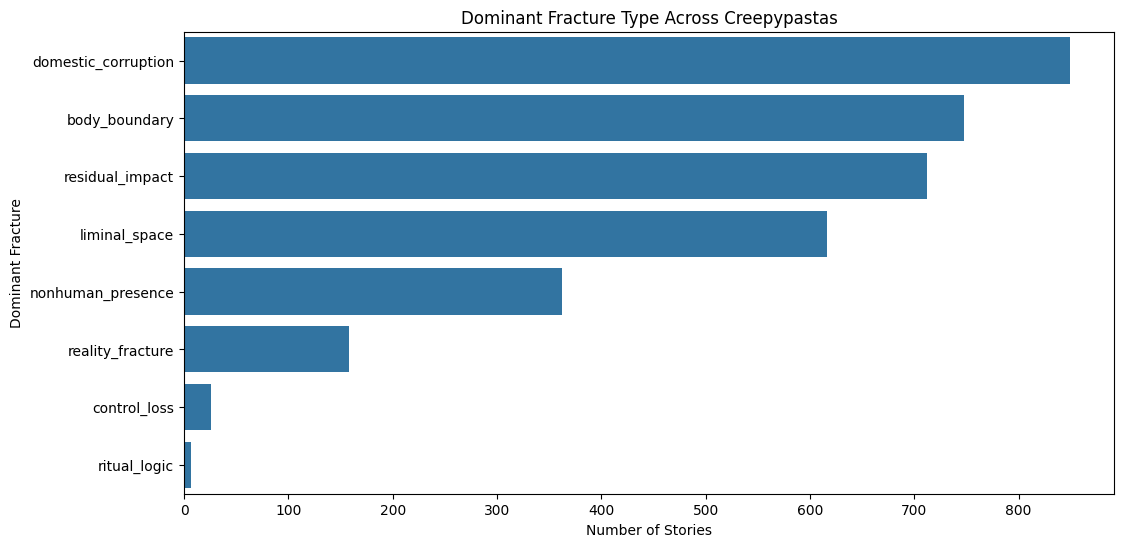

In [15]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=dominant_fracture_counts.values,
    y=dominant_fracture_counts.index
)

plt.title("Dominant Fracture Type Across Creepypastas")
plt.xlabel("Number of Stories")
plt.ylabel("Dominant Fracture")

plt.show()

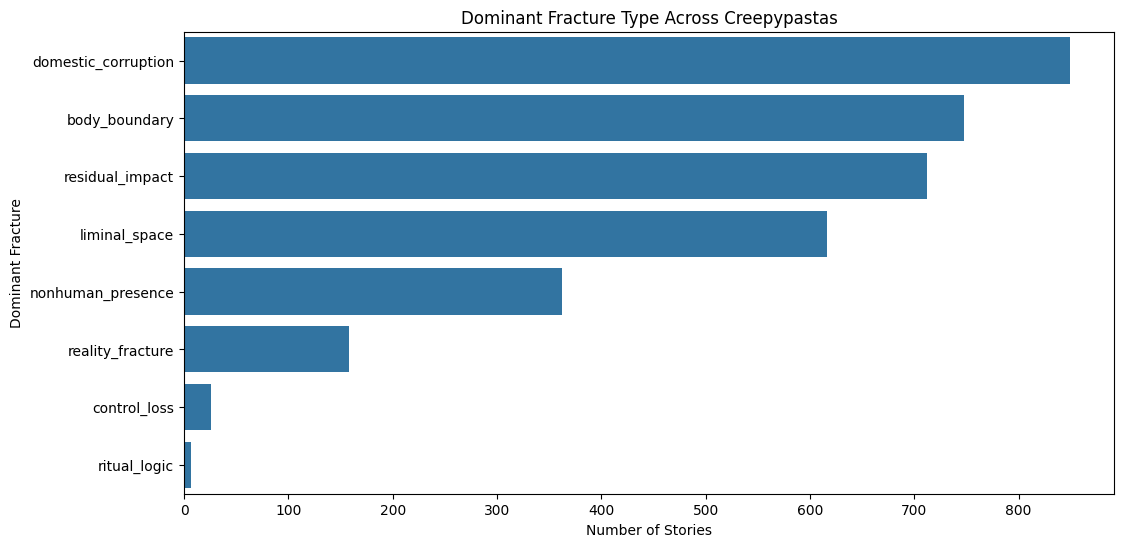

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=dominant_fracture_counts.values,
    y=dominant_fracture_counts.index
)

plt.title("Dominant Fracture Type Across Creepypastas")
plt.xlabel("Number of Stories")
plt.ylabel("Dominant Fracture")

plt.show()

In [17]:
df["horror_fracture_index_per_1000"] = df["horror_fracture_index"] * 1000

df[["title", "rating_numeric", "word_count", "horror_fracture_index", "horror_fracture_index_per_1000"]].head()

,title,rating_numeric,word_count,horror_fracture_index,horror_fracture_index_per_1000
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me",9.25,3560,0.006145,6.144663
1,A Shattered Life,9.13,3919,0.006571,6.570554
2,My Father Punished Me When I Talked to Ghosts,9.12,2135,0.008021,8.021077
3,Distorted Warning Signals,9.12,768,0.007161,7.161458
4,He Who Wanders,9.12,6021,0.005751,5.750706


In [18]:
df["horror_fracture_index_per_1000"].describe()

count    3478.000000
mean        7.196881
std         2.432780
min         0.000000
25%         5.534506
50%         6.936553
75%         8.635426
max        23.923445
Name: horror_fracture_index_per_1000, dtype: float64

In [19]:
df_long_enough = df[df["word_count"] >= 500].copy()

top_fracture_stories_filtered = (
    df_long_enough
    .sort_values("horror_fracture_index_per_1000", ascending=False)
    .head(20)
)

top_fracture_stories_filtered[
    [
        "title",
        "rating_numeric",
        "word_count",
        "horror_fracture_index_per_1000",
        "dominant_fracture"
    ]
]

,title,rating_numeric,word_count,horror_fracture_index_per_1000,dominant_fracture
2861,The Shadow Being,6.62,699,16.988555,domestic_corruption
1496,The Gaunt Man,7.97,557,16.606822,residual_impact
609,The Darkness,8.62,2145,15.209790,domestic_corruption
571,One More For The Orphan,8.65,526,14.971483,liminal_space
1309,Let Me In,8.10,643,14.968896,liminal_space
1370,Scraggly Hair,8.06,1444,14.889197,liminal_space
2584,Still Here,7.01,639,14.866980,residual_impact
3183,Amelia,5.86,1101,14.078111,domestic_corruption
2486,The Blanket Monster,7.13,944,14.036017,domestic_corruption
1381,Ink Filled Dream,8.05,1557,13.969171,domestic_corruption


In [20]:
hfi_rating_correlation = df["horror_fracture_index_per_1000"].corr(df["rating_numeric"])

print("Correlation between Horror Fracture Index and rating:", hfi_rating_correlation)

Correlation between Horror Fracture Index and rating: -0.024912125506453706


In [21]:
fracture_rating_correlations = (
    df[normalized_fracture_columns + ["rating_numeric"]]
    .corr()["rating_numeric"]
    .drop("rating_numeric")
    .sort_values(ascending=False)
)

fracture_rating_correlations

domestic_corruption_normalized    0.033257
control_loss_normalized           0.017617
liminal_space_normalized          0.000835
residual_impact_normalized       -0.009447
nonhuman_presence_normalized     -0.038272
ritual_logic_normalized          -0.047211
reality_fracture_normalized      -0.047543
body_boundary_normalized         -0.048970
Name: rating_numeric, dtype: float64

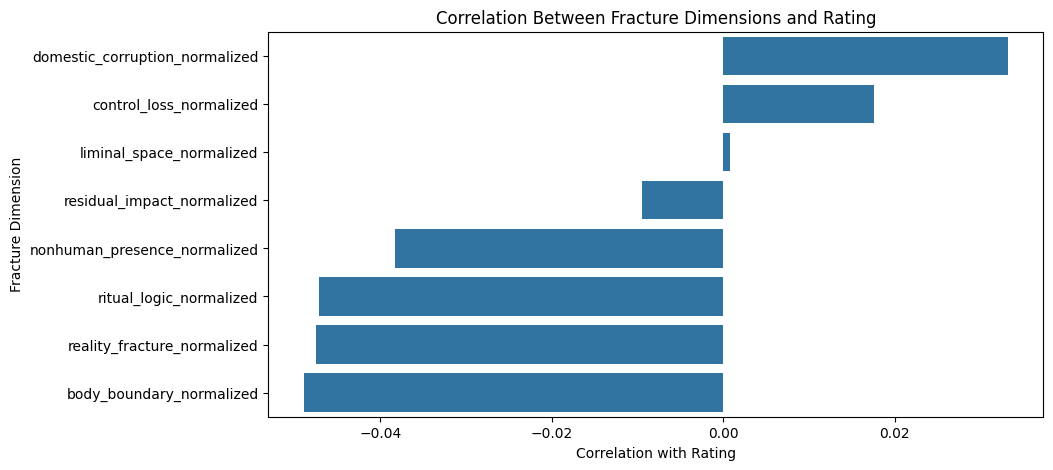

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=fracture_rating_correlations.values,
    y=fracture_rating_correlations.index
)

plt.title("Correlation Between Fracture Dimensions and Rating")
plt.xlabel("Correlation with Rating")
plt.ylabel("Fracture Dimension")

plt.show()

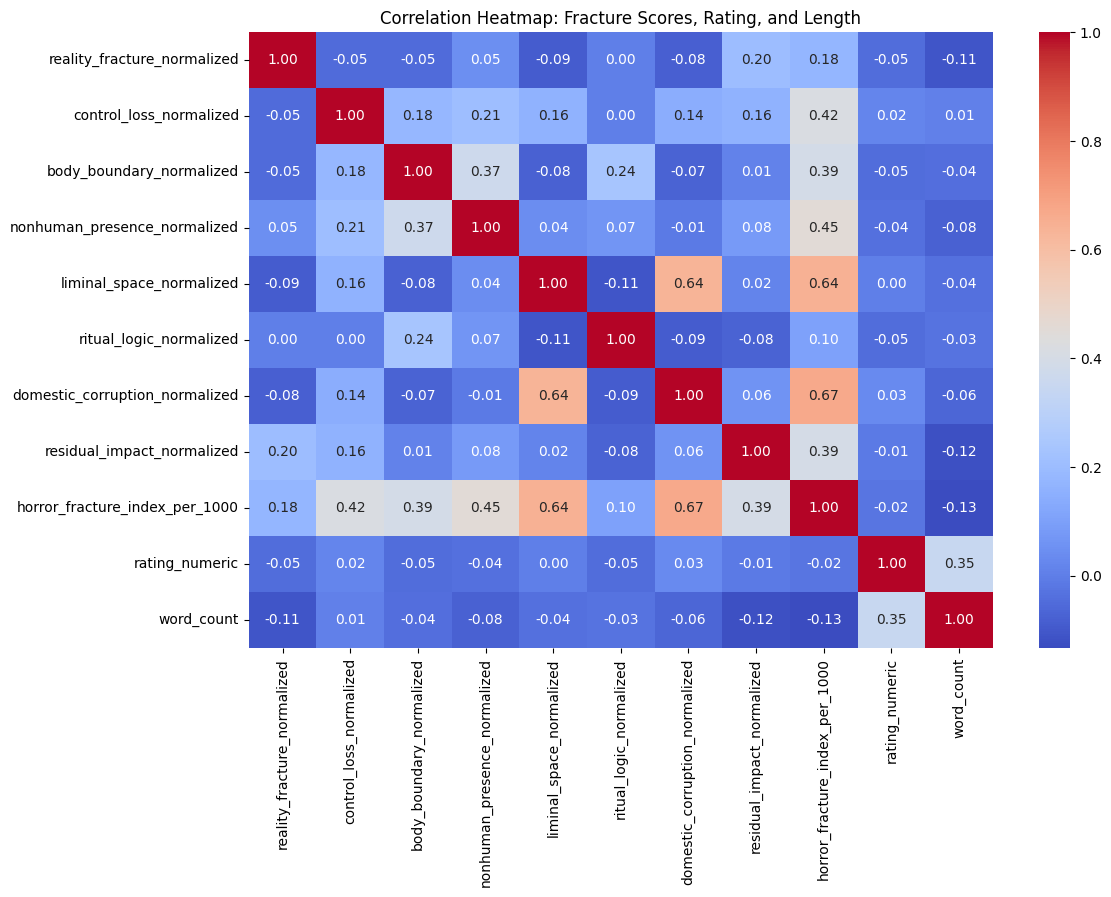

In [23]:
correlation_columns = normalized_fracture_columns + [
    "horror_fracture_index_per_1000",
    "rating_numeric",
    "word_count"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap: Fracture Scores, Rating, and Length")

plt.show()

In [24]:
rating_threshold = df["rating_numeric"].quantile(0.75)

df["high_rating"] = (df["rating_numeric"] >= rating_threshold).astype(int)

print("High rating threshold:", rating_threshold)
print(df["high_rating"].value_counts())

High rating threshold: 8.42
high_rating
0    2602
1     876
Name: count, dtype: int64


In [25]:
high_rating_comparison = (
    df.groupby("high_rating")[normalized_fracture_columns + ["horror_fracture_index_per_1000"]]
    .mean()
    .T
)

high_rating_comparison.columns = ["low_or_mid_rating", "high_rating"]

high_rating_comparison["difference"] = (
    high_rating_comparison["high_rating"] - high_rating_comparison["low_or_mid_rating"]
)

high_rating_comparison.sort_values("difference", ascending=False)

,low_or_mid_rating,high_rating,difference
domestic_corruption_normalized,0.010228,0.011233,0.001005
liminal_space_normalized,0.009265,0.009379,0.000114
ritual_logic_normalized,0.001361,0.001329,-0.000032
control_loss_normalized,0.004169,0.004119,-0.000049
reality_fracture_normalized,0.005290,0.005042,-0.000248
residual_impact_normalized,0.010082,0.009810,-0.000272
nonhuman_presence_normalized,0.008464,0.007599,-0.000865
body_boundary_normalized,0.009024,0.008147,-0.000877
horror_fracture_index_per_1000,7.235448,7.082324,-0.153124


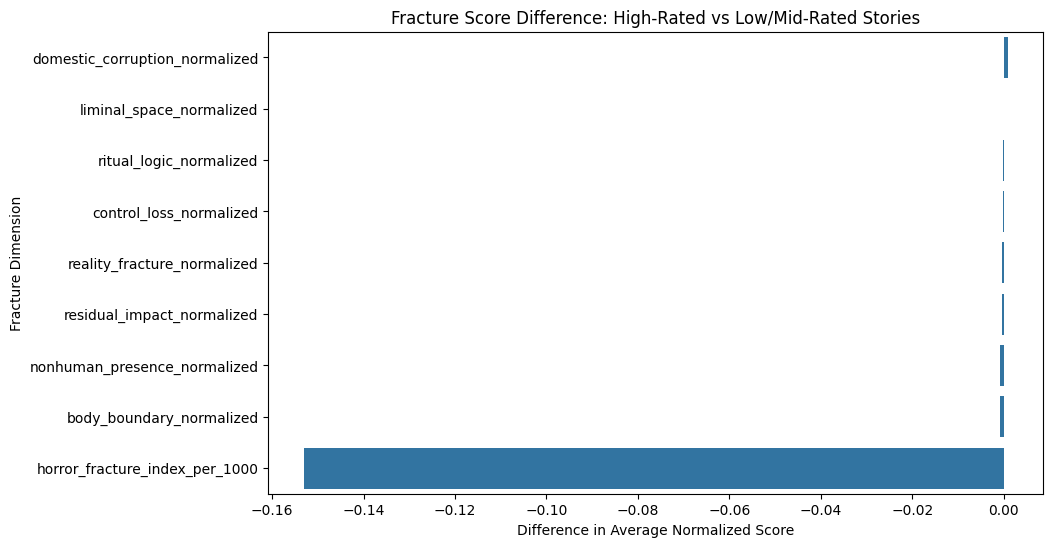

In [26]:
comparison_sorted = high_rating_comparison.sort_values("difference", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=comparison_sorted["difference"],
    y=comparison_sorted.index
)

plt.title("Fracture Score Difference: High-Rated vs Low/Mid-Rated Stories")
plt.xlabel("Difference in Average Normalized Score")
plt.ylabel("Fracture Dimension")

plt.show()

In [27]:
dominant_fracture_rating = (
    df.groupby("dominant_fracture")["rating_numeric"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

dominant_fracture_rating

,count,mean
dominant_fracture,,
domestic_corruption,849,7.722144
residual_impact,712,7.646587
ritual_logic,7,7.578571
liminal_space,616,7.548393
nonhuman_presence,362,7.484807
body_boundary,748,7.462714
control_loss,26,7.456154
reality_fracture,158,7.135380


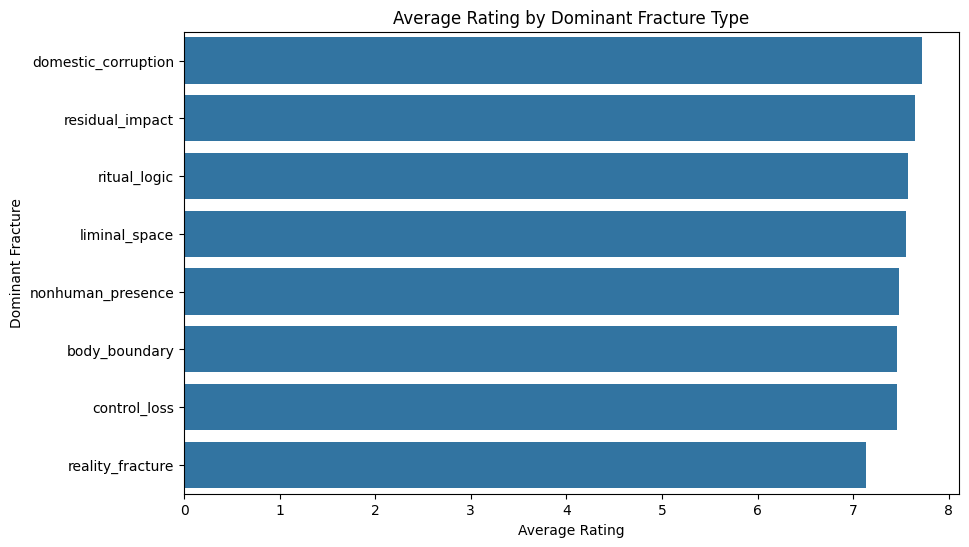

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=dominant_fracture_rating.reset_index(),
    x="mean",
    y="dominant_fracture"
)

plt.title("Average Rating by Dominant Fracture Type")
plt.xlabel("Average Rating")
plt.ylabel("Dominant Fracture")

plt.show()

In [29]:
df.to_csv(FRACTURE_DATA_PATH, index=False, encoding="utf-8")

print("Fracture index dataset saved in:")
print(FRACTURE_DATA_PATH)

Fracture index dataset saved in:
../data/processed/creepypastas_fracture_index.csv


In [30]:
df_check = pd.read_csv(FRACTURE_DATA_PATH)

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])

df_check.head()

Rows: 3478
Columns: 32


,title,story_text,text_lower,rating,rating_numeric,story_length_chars,word_count,tags,categories,estimated_reading_time,publish_date,primary_category,reality_fracture_score,control_loss_score,body_boundary_score,nonhuman_presence_score,liminal_space_score,ritual_logic_score,domestic_corruption_score,residual_impact_score,reality_fracture_normalized,control_loss_normalized,body_boundary_normalized,nonhuman_presence_normalized,liminal_space_normalized,ritual_logic_normalized,domestic_corruption_normalized,residual_impact_normalized,horror_fracture_index,dominant_fracture,horror_fracture_index_per_1000,high_rating
0,"If You’re Armed and at the Glenmont Metro, Please Shoot Me","If you’re armed and at the Glenmont metro, please shoot me.\nMake it a headshot. Shoot me in the temple, aiming slightly downwards. I need the bullet to travel the shortest possible distance throu...","if you’re armed and at the glenmont metro, please shoot me.\nmake it a headshot. shoot me in the temple, aiming slightly downwards. i need the bullet to travel the shortest possible distance throu...",9.25,9.25,19493,3560,"drug trials, drugs, experimentation, experiments, madness, Peter Frost David, psychological, psychological horror, sci-fi, science, science fiction, time","Drugs and Addictions, Madness, Paranoia, and Mental Illness, Psychological Horror, Science and Experimentation, Science Fiction and Aliens",12 minutes,2020-02-20,Drugs and Addictions,34,15,39,10,23,1,16,37,0.009551,0.004213,0.010955,0.002809,0.006461,0.000281,0.004494,0.010393,0.006145,body_boundary,6.144663,1
1,A Shattered Life,"I don’t know when you’re going to read this, but I can tell you when it started: I was out for a walk alone in the woods when the entity came for me. It was beyond a blur. It was, for lack of a be...","i don’t know when you’re going to read this, but i can tell you when it started: i was out for a walk alone in the woods when the entity came for me. it was beyond a blur. it was, for lack of a be...",9.13,9.13,20837,3919,"disease, entities, Matt Dymerski, monsters, paranormal, supernatural, time travel","Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Science Fiction and Aliens",14 minutes,2020-07-22,Madness,30,11,27,31,31,0,26,50,0.007655,0.002807,0.006890,0.007910,0.007910,0.000000,0.006634,0.012758,0.006571,residual_impact,6.570554,1
2,My Father Punished Me When I Talked to Ghosts,"I’ve been blind since birth. As I grew up, everything was described to me in such vivid detail that I didn’t even realize why it was that important to see, especially having no reference point to ...","i’ve been blind since birth. as i grew up, everything was described to me in such vivid detail that i didn’t even realize why it was that important to see, especially having no reference point to ...",9.12,9.12,10859,2135,"abductions, blindness, child abuse, childhood, children, crimes, deaths, deception, investigations, kidnappings, kids, lies, murders","Abductions and Kidnappings, Children and Childhood, Deaths, Murders, and Disappearances, Investigations and Crimes",8 minutes,2019-12-10,Abductions and Kidnappings,10,11,21,15,19,1,37,23,0.004684,0.005152,0.009836,0.007026,0.008899,0.000468,0.017330,0.010773,0.008021,domestic_corruption,8.021077,1
3,Distorted Warning Signals,"When I got the first one, I was literally seconds away from stepping onto the plane when a call from “UNKNOWN” blared from my cell phone. It was a ringtone I hadn’t heard before, one I was pretty ...","when i got the first one, i was literally seconds away from stepping onto the plane when a call from “unknown” blared from my cell phone. it was a ringtone i hadn’t heard before, one i was pretty ...",9.12,9.12,4150,768,Ashley Rose Wellman,"Beings and Entities, Deaths, Murders, and Disappearances, Madness, Paranoia, and Mental Illness, Monsters, Creatures, and Cryptids, Occult, Magic, and Witchcraft, Psychological Horror, Survival Ho...",3 minutes,2019-07-13,Beings and Entities,3,4,2,15,2

Horror Fracture Index Conclusions

This notebook created the Horror Fracture Index, a custom NLP-based scoring system designed to measure different types of perceptual rupture in creepypasta stories.

The index was built using eight narrative fracture dimensions:

- Reality fracture
- Control loss
- Body boundary
- Nonhuman presence
- Liminal space
- Ritual logic
- Domestic corruption
- Residual impact

Each story received raw keyword scores and normalized scores by word count. The final Horror Fracture Index represents the average density of these fracture signals.

The first results suggest that domestic corruption, body boundary, residual impact, and liminal space are the most common dominant fracture types in the dataset.

Because very short stories can produce extremely high normalized scores, a filtered version using stories with at least 500 words was also created for fairer interpretation.

The next step is to use these fracture features for optional modeling and final storytelling insights.